In [9]:
import sys
import torch
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

from src.dataloader import MusdbDataset
from src.preprocess import AudioPreprocessor

print("Libraries and custom modules loaded.")

Libraries and custom modules loaded.


In [10]:
DATASET_PATH = "./data/musdb18_hq/train"

try:
    dataset = MusdbDataset(dataset_root=DATASET_PATH, segment_length=256)
    print(f"Successfully initialized MusdbDataset.")
    print(f"Total stochastic track pairs indexed: {len(dataset)}")
except Exception as e:
    print("Error loading dataset.")
    print(e)

Successfully initialized MusdbDataset.
Total stochastic track pairs indexed: 1200


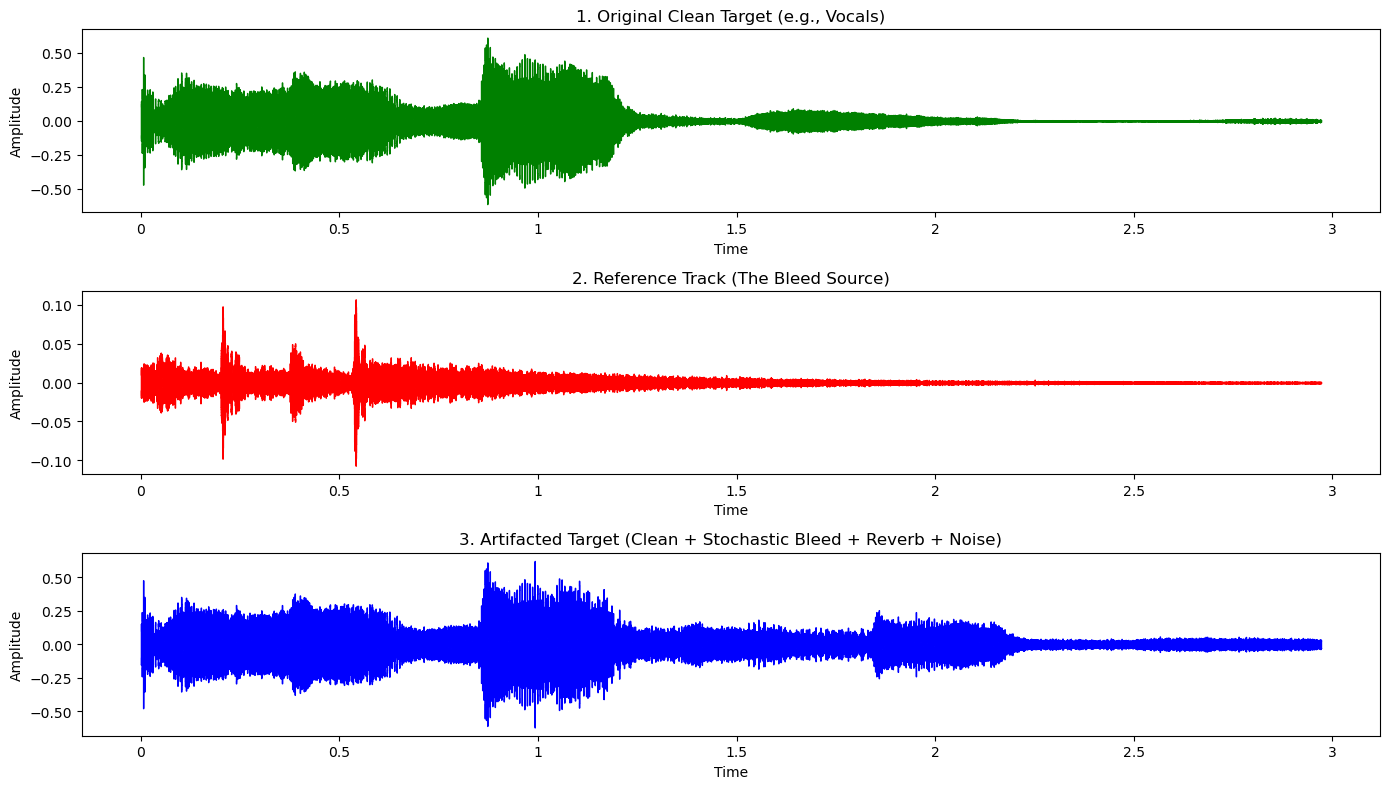

In [11]:
artifacted_wav, reference_wav, clean_wav = dataset[0]

art_np = artifacted_wav.squeeze().numpy()
ref_np = reference_wav.squeeze().numpy()
clean_np = clean_wav.squeeze().numpy()
sr = 44100

plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
librosa.display.waveshow(clean_np, sr=sr, color='green')
plt.title('1. Original Clean Target (e.g., Vocals)')
plt.ylabel('Amplitude')

plt.subplot(3, 1, 2)
librosa.display.waveshow(ref_np, sr=sr, color='red')
plt.title('2. Reference Track (The Bleed Source)')
plt.ylabel('Amplitude')

plt.subplot(3, 1, 3)
librosa.display.waveshow(art_np, sr=sr, color='blue')
plt.title('3. Artifacted Target (Clean + Stochastic Bleed + Reverb + Noise)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

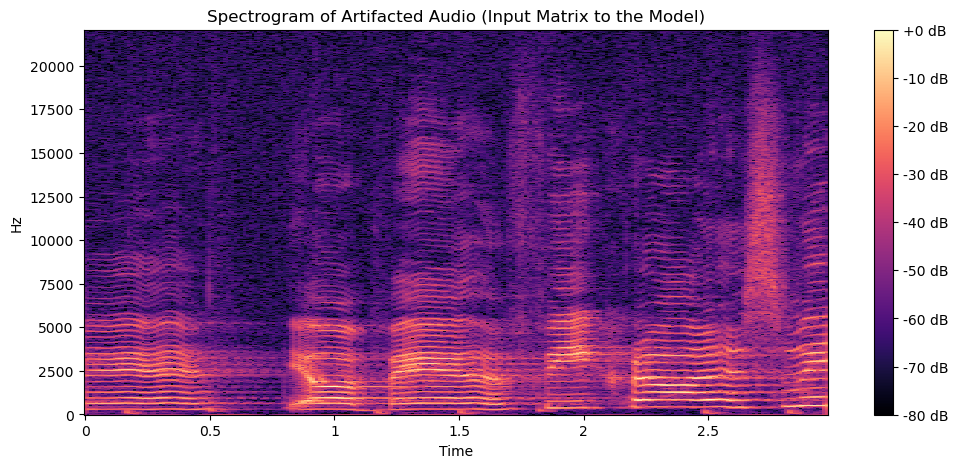

In [8]:
processor = AudioPreprocessor(sample_rate=sr, n_fft=2048, max_freq=16000)

complex_art = processor.waveform_to_complex_stft(artifacted_wav.unsqueeze(0))
mag_art = torch.abs(complex_art).squeeze().numpy()

plt.figure(figsize=(12, 5))
librosa.display.specshow(librosa.amplitude_to_db(mag_art, ref=np.max), 
                         sr=sr, hop_length=processor.hop_length, 
                         y_axis='hz', x_axis='time', cmap='magma')
plt.title('Spectrogram of Artifacted Audio (Input Matrix to the Model)')
plt.colorbar(format='%+2.0f dB')
plt.show()